選択銘柄:
- IOTA (iota) id=iota
- AWE Network (awe) id=stp-network
- Zano (zano) id=zano
- Ozone Chain (ozo) id=ozone-chain
- BNB (bnb) id=binancecoin

取得エラー（あった分だけ表示）:
   rate_limited: binancecoin


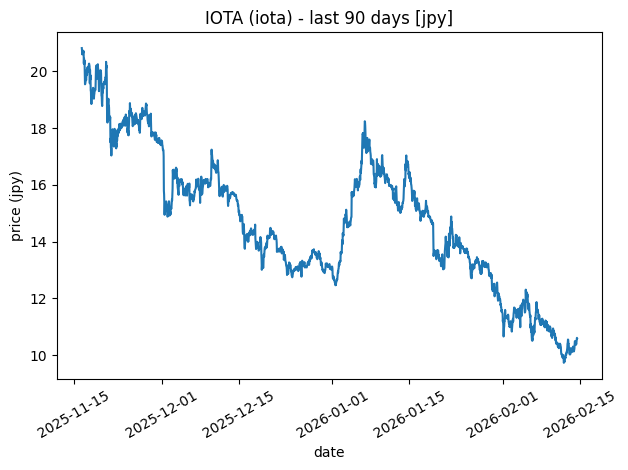

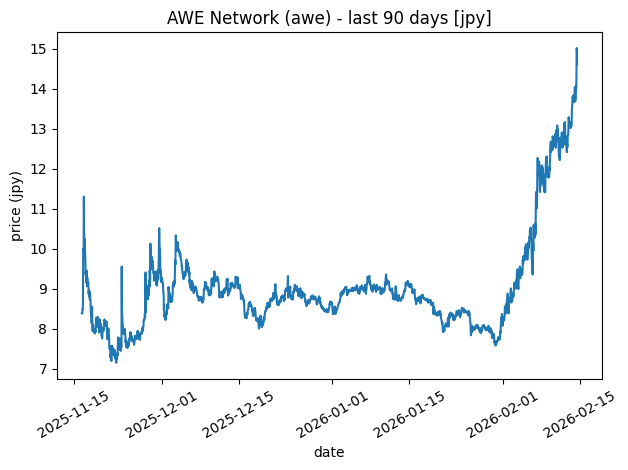

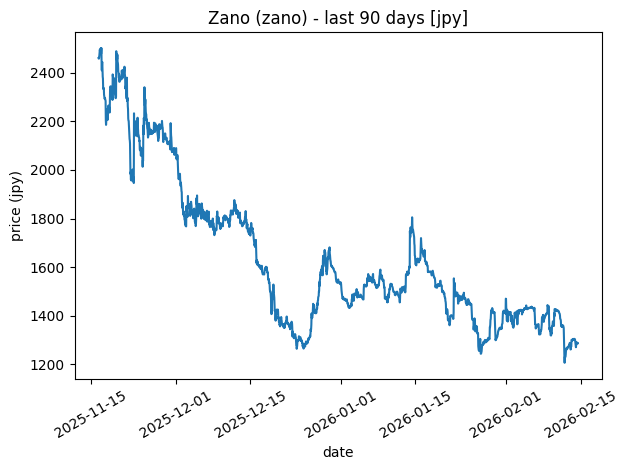

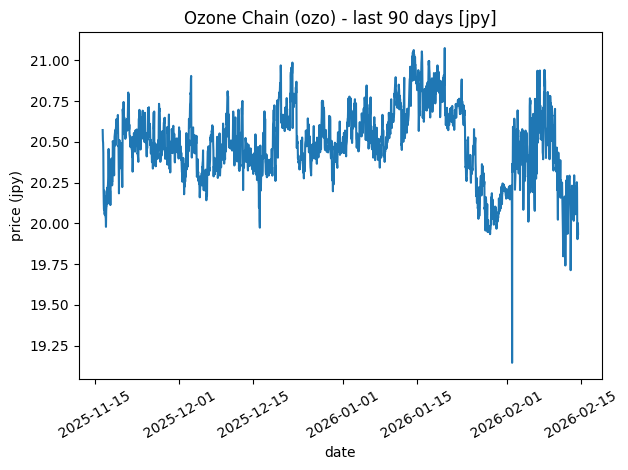

In [4]:
import time
import random
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone

# =========================
# 設定
# =========================
VS = "jpy"                 # 通貨（usd / jpy など）
N_COINS = 5                # 取得する銘柄数
TOP_N_POOL = 250           # 上位何件からランダム抽出するか
SPAN_MODE = "days"         # "days" or "minutes"
DAYS = 90                  # SPAN_MODE="days" のとき
MINUTES = 90               # SPAN_MODE="minutes" のとき
SLEEP_SEC = 1.5            # レート制限対策（必要なら増やす）
TIMEOUT = 30

BASE = "https://api.coingecko.com/api/v3"

# =========================
# ユーティリティ
# =========================
def get_json(url, params=None):
    r = requests.get(url, params=params, timeout=TIMEOUT)
    if r.status_code == 429:
        # レート制限
        return {"__rate_limited__": True, "status_code": 429, "text": r.text}
    if not r.ok:
        return {"__http_error__": True, "status_code": r.status_code, "text": r.text}
    return r.json()

def pick_random_top_coins(n=N_COINS, pool=TOP_N_POOL):
    url = f"{BASE}/coins/markets"
    params = {
        "vs_currency": VS,
        "order": "market_cap_desc",
        "per_page": pool,
        "page": 1
    }
    data = get_json(url, params=params)
    if isinstance(data, dict) and ("__http_error__" in data or "__rate_limited__" in data):
        raise RuntimeError(f"coins/markets 取得失敗: {data}")
    # data: list of dicts, each has 'id','symbol','name'
    return random.sample(data, n)

def fetch_prices_series(coin_id):
    if SPAN_MODE == "days":
        url = f"{BASE}/coins/{coin_id}/market_chart"
        params = {"vs_currency": VS, "days": DAYS}
        data = get_json(url, params=params)
    elif SPAN_MODE == "minutes":
        # 直近 MINUTES 分のレンジを epoch 秒で指定（UTC）
        now = datetime.now(timezone.utc)
        frm = int((now - timedelta(minutes=MINUTES)).timestamp())
        to = int(now.timestamp())
        url = f"{BASE}/coins/{coin_id}/market_chart/range"
        params = {"vs_currency": VS, "from": frm, "to": to}
        data = get_json(url, params=params)
    else:
        raise ValueError("SPAN_MODE must be 'days' or 'minutes'")

    # エラー処理
    if isinstance(data, dict) and data.get("__rate_limited__"):
        return None, f"rate_limited: {coin_id}"
    if isinstance(data, dict) and data.get("__http_error__"):
        return None, f"http_error {data['status_code']}: {coin_id}"
    if not isinstance(data, dict) or "prices" not in data:
        return None, f"no_prices: {coin_id} data={data}"

    prices = data["prices"]  # [[ms, price], ...]
    df = pd.DataFrame(prices, columns=["timestamp_ms", "price"])
    df["date"] = pd.to_datetime(df["timestamp_ms"], unit="ms", utc=True).dt.tz_convert("Asia/Tokyo")
    df = df[["date", "price"]].dropna()
    return df, None

# =========================
# 実行
# =========================
coins = pick_random_top_coins()
print("選択銘柄:")
for c in coins:
    print(f"- {c['name']} ({c['symbol']}) id={c['id']}")

series_list = []
errors = []

for c in coins:
    coin_id = c["id"]
    df, err = fetch_prices_series(coin_id)
    if err:
        errors.append(err)
    else:
        series_list.append((c["name"], c["symbol"], coin_id, df))
    time.sleep(SLEEP_SEC)

if errors:
    print("\n取得エラー（あった分だけ表示）:")
    for e in errors:
        print("  ", e)

if not series_list:
    raise RuntimeError("全部失敗しました。SLEEP_SEC を増やすか、しばらく待って再実行してください。")

# =========================
# プロット（銘柄ごとに1枚）
# =========================
for name, symbol, coin_id, df in series_list:
    plt.figure()
    plt.plot(df["date"], df["price"])
    if SPAN_MODE == "days":
        plt.title(f"{name} ({symbol}) - last {DAYS} days [{VS}]")
    else:
        plt.title(f"{name} ({symbol}) - last {MINUTES} minutes [{VS}]")
    plt.xlabel("date")
    plt.ylabel(f"price ({VS})")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
